In [91]:
#ucitavanje potrebnih biblioteka
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ndcg_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import time
import scipy.stats as stats
import matplotlib.pyplot as plt

In [92]:
# Ucitavanje podataka
df = pd.read_csv("C:\\Users\\Hp\\Documents\\Formula1\\tables\\zaModel.csv")

In [93]:
df = df.drop('Unnamed: 0', axis=1)

In [94]:
# izbaciti redove za koje se ne zna ime i pozicija vozaca
df = df.dropna(subset=["position_race", "race_name"])
# Umesto nan vrednosti stavlja se -1
df["position_quali"] = df["position_quali"].fillna(-1)

In [95]:
# pravimo group id-jeve po sezoni i rundi
df["group_id"] = df["season"].astype(str) + "_" + df["round"].astype(str)

In [96]:
#label enkodovanje imena staze
le = LabelEncoder()
df["circuit"] = le.fit_transform(df["circuit"])
le = LabelEncoder()
df["driverId"] = le.fit_transform(df["driverId"])
le = LabelEncoder()
df["constructor"] = le.fit_transform(df["constructor"])
le = LabelEncoder()
df["race_name"] = le.fit_transform(df["race_name"])

In [97]:
# Izbacivanje nepotrebnih kolona
# drop_cols = ["status", "driver", "constructor", "_merge",
#              "race_name", "total_time_ms", 'laps', 'points', 'num_pit_stops', 
#              'lap_pit_stops', 'duration_pit_stops', 'best_qual_time', 'position_quali', 'num_overtakes']
# df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [98]:
# uklanjamo target kolonu i group_id jer se on koristi samo za split 
features = df.drop(columns=["position_race", "group_id"])
target = 21 - df["position_race"]

In [99]:
# Hronoloski split
unique_races_sorted = (
    df[["season", "round", "group_id"]]
    .drop_duplicates()
    .sort_values(["season", "round"])
)["group_id"].values

# Train (70%) / Val (10%) / Test (20%) split
num_races = len(unique_races_sorted)
train_end = int(0.7 * num_races)
val_end = int(0.8 * num_races)

train_races = unique_races_sorted[:train_end]
val_races = unique_races_sorted[train_end:val_end]
test_races = unique_races_sorted[val_end:]

train_mask = df["group_id"].isin(train_races)
val_mask = df["group_id"].isin(val_races)
test_mask = df["group_id"].isin(test_races)

X_train = features[train_mask]
y_train = target[train_mask]
X_val = features[val_mask]
y_val = target[val_mask]
X_test = features[test_mask]
y_test = target[test_mask]

group_sizes_train = df[train_mask].groupby("group_id").size().values
group_sizes_val = df[val_mask].groupby("group_id").size().values
group_sizes_test = df[test_mask].groupby("group_id").size().values

In [100]:
# Pravljenje DMatrix-a

dtrain = xgb.DMatrix(X_train, label=y_train)
dtrain.set_group(group_sizes_train)

dval = xgb.DMatrix(X_val, label=y_val)
dval.set_group(group_sizes_val)

dtest = xgb.DMatrix(X_test, label=y_test)
dtest.set_group(group_sizes_test)

In [101]:
df.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'constructor', 'grid', 'driverId', 'race_name', 'circuit', 'lap_length',
       'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5',
       'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms',
       'group_id'],
      dtype='object')

In [102]:
#  pronalazenje hiperparametara

def objective(trial):
    params = {
        "objective": "rank:ndcg",
        "eval_metric": "ndcg",
        "eta": trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "lambda": trial.suggest_float("lambda", 0, 5),
        "alpha": trial.suggest_float("alpha", 0, 5),
    }

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=100,
        evals=[(dval, "validation")],
        early_stopping_rounds=10,
        verbose_eval=False
    )

    preds = model.predict(dval)

    df_val_copy = df[val_mask].copy()
    df_val_copy["pred_score"] = preds

    ndcg_list = []
    for _, group in df_val_copy.groupby("group_id"):
        if group.shape[0] < 2:
            continue
        true_rel = 21 - group["position_race"].values
        pred_score = group["pred_score"].values
        ndcg = ndcg_score([true_rel], [pred_score])
        ndcg_list.append(ndcg)

    return np.mean(ndcg_list)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)

[I 2025-07-03 19:23:10,715] A new study created in memory with name: no-name-c5f19c75-73ba-4e89-89ba-db510edbadd1
[I 2025-07-03 19:23:10,880] Trial 0 finished with value: 0.9548103272947269 and parameters: {'eta': 0.2746265056438813, 'max_depth': 9, 'min_child_weight': 3, 'gamma': 3.5024890303800955, 'subsample': 0.6225249523926497, 'colsample_bytree': 0.5755372066298996, 'lambda': 1.0234818456870394, 'alpha': 0.17544094518263886}. Best is trial 0 with value: 0.9548103272947269.
[I 2025-07-03 19:23:11,042] Trial 1 finished with value: 0.9564424219417672 and parameters: {'eta': 0.04995546929109022, 'max_depth': 8, 'min_child_weight': 1, 'gamma': 0.28594553544721846, 'subsample': 0.8553185570530499, 'colsample_bytree': 0.892512099676106, 'lambda': 2.8368728451881386, 'alpha': 4.682898555921974}. Best is trial 1 with value: 0.9564424219417672.
[I 2025-07-03 19:23:11,167] Trial 2 finished with value: 0.9562445360561201 and parameters: {'eta': 0.2703921880466543, 'max_depth': 4, 'min_child_

Best hyperparameters:
{'eta': 0.20938897321861838, 'max_depth': 9, 'min_child_weight': 7, 'gamma': 0.019827905332156615, 'subsample': 0.8534148498543885, 'colsample_bytree': 0.7474895505499904, 'lambda': 4.378942215990201, 'alpha': 0.3503520803840143}


In [103]:
params = study.best_params
params["objective"] = "rank:ndcg"
params["eval_metric"] = "ndcg"

#treniranje modela
model = xgb.train(
    params,
    dtrain,
    num_boost_round=100,
    evals=[(dval, "validation")],
    early_stopping_rounds=10
)

# cuvanje modela
model.save_model(f"models_camp/xgb_ranker_with_val_{time.time()}.model")

print("Model trained and saved successfully.")


[0]	validation-ndcg:0.70171


[1]	validation-ndcg:0.85215
[2]	validation-ndcg:0.88119
[3]	validation-ndcg:0.90121
[4]	validation-ndcg:0.88278
[5]	validation-ndcg:0.90164
[6]	validation-ndcg:0.90713
[7]	validation-ndcg:0.90445
[8]	validation-ndcg:0.91115
[9]	validation-ndcg:0.90964
[10]	validation-ndcg:0.90932
[11]	validation-ndcg:0.90599
[12]	validation-ndcg:0.92389
[13]	validation-ndcg:0.92671
[14]	validation-ndcg:0.92116
[15]	validation-ndcg:0.92142
[16]	validation-ndcg:0.90822
[17]	validation-ndcg:0.90785
[18]	validation-ndcg:0.92412
[19]	validation-ndcg:0.91238
[20]	validation-ndcg:0.91529
[21]	validation-ndcg:0.92457
[22]	validation-ndcg:0.90985
[23]	validation-ndcg:0.90904
Model trained and saved successfully.


C:\Users\Hp\AppData\Local\Temp\ipykernel_11056\1989846895.py:15: UserWarning: [19:23:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  model.save_model(f"models_camp/xgb_ranker_with_val_{time.time()}.model")


In [104]:
# Predvidjanja modela
y_pred_scores = model.predict(dtest)


df_test = df[test_mask].copy()
df_test["pred_score"] = y_pred_scores

df_test['position_race'] = pd.to_numeric(df_test['position_race'], errors='coerce')
df_test['pred_score'] = pd.to_numeric(df_test['pred_score'], errors='coerce')


race_groups = df_test.groupby("group_id")

In [105]:
# Metrike
ndcg_list = []
tau_list = []
spearman_list = []

for race_id, group in race_groups:
    if group.shape[0] < 2:
        continue  # preskacu se trke sa manje od dva vozaca

    true_ranks = group["position_race"].values
    pred_scores = group["pred_score"].values

    # relevantnost 21 - pozicija, jer ndcg ocekuje vece = bolje
    true_relevance = 21 - true_ranks
    ndcg = ndcg_score([true_relevance], [pred_scores])
    ndcg_list.append(ndcg)

    # Kendall's Tau i Spermanova korelacija
    tau, _ = stats.kendalltau(-true_ranks, pred_scores)
    spearman, _ = stats.spearmanr(-true_ranks, pred_scores)
    tau_list.append(tau)
    spearman_list.append(spearman)


print(f"Evaluation Metrics Across Races:")
print(f"Average NDCG: {np.mean(ndcg_list):.4f}")
print(f"Average Kendall's Tau: {np.nanmean(tau_list):.4f}")
print(f"Average Spearman: {np.nanmean(spearman_list):.4f}")


Evaluation Metrics Across Races:
Average NDCG: 0.9623
Average Kendall's Tau: 0.5576
Average Spearman: 0.6930


In [106]:
all_predictions = pd.DataFrame()
for race_id, group in race_groups:
    if group.shape[0] < 2:
        continue  # preskacu se trke sa manje od dva vozaca


    one_race = group[['pred_score']].copy()  
    one_race['pred_rank'] = group['pred_score'].rank(ascending=False, method='first').to_frame()
    one_race['position_race'] = group['position_race']
    all_predictions = pd.concat([all_predictions, one_race])


In [111]:
from sklearn.metrics import root_mean_squared_error


true_positions = df_test["position_race"].values
pred_scores = df_test["pred_score"].values

#konvertovanje skorova modela u rank
predicted_ranks = race_groups["pred_score"].rank(ascending=False)

# Compute RMSE
rmse = root_mean_squared_error(true_positions, predicted_ranks)

print(f"RMSE between predicted and actual positions: {rmse:.4f}")


RMSE between predicted and actual positions: 4.5119


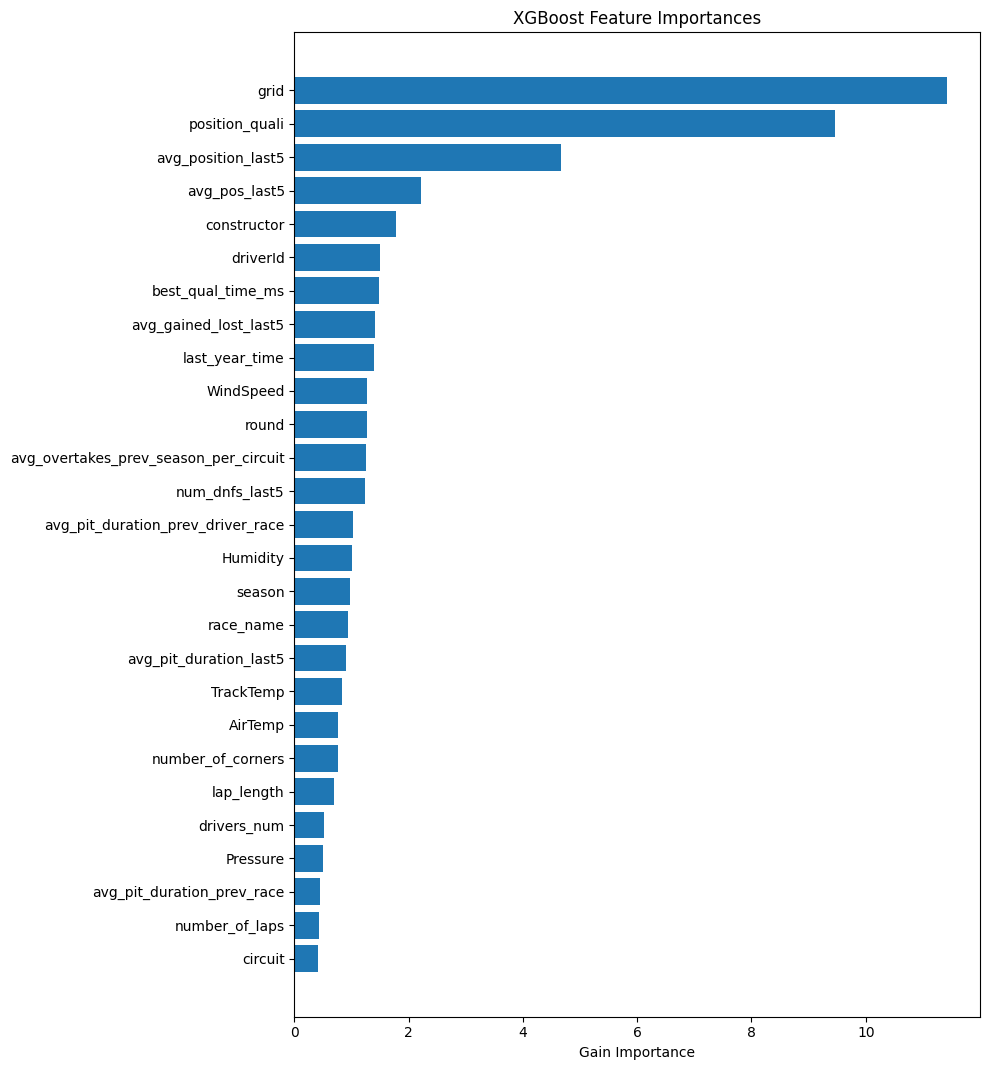

In [112]:
import matplotlib.pyplot as plt

# feature importances
importances = model.get_score(importance_type='gain')  # 'weight', 'cover', 'total_gain', 'total_cover'

# konvertovanje u sortiran df
importance_df = pd.DataFrame({
    "Feature": list(importances.keys()),
    "Importance": list(importances.values())
}).sort_values(by="Importance", ascending=False)


# plotovanje
plt.figure(figsize=(10, len(importance_df) * 0.4))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Gain Importance")
plt.title("XGBoost Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [113]:
# broj feature-a u datasetu
print(X_train.columns.tolist())
print(f"Total features in dataset: {X_train.shape[1]}")

['season', 'round', 'drivers_num', 'position_quali', 'constructor', 'grid', 'driverId', 'race_name', 'circuit', 'lap_length', 'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity', 'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction', 'is_sprint_weekend', 'last_year_time', 'avg_position_last5', 'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5', 'avg_pit_duration_last5', 'avg_pit_duration_prev_race', 'avg_pit_duration_prev_driver_race', 'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms']
Total features in dataset: 30


In [114]:
# feature-i koji nisu iskorisceni 
used_features = list(model.get_score(importance_type='gain').keys())
print(f"Features used by model: {len(used_features)}")
print(f"Unused features: {set(X_train.columns) - set(used_features)}")

Features used by model: 27
Unused features: {'wind_direction', 'rain_bin', 'is_sprint_weekend'}


In [118]:
some_race_id = df_test['group_id'].unique()[14] #14

# Izdvajanje jedne trke
race_df = df_test[df_test['group_id'] == some_race_id].copy()

# Predikcija plasmana
race_df['predicted_rank'] = race_df['pred_score'].rank(ascending=False, method='first')
race_df['true_rank'] = race_df['position_race']

# Sortiranje po predikciji
race_df = race_df.sort_values('predicted_rank')

# Tabela stvarne vs predvidjene vredvosti, i pred score
display_columns = ['drivers_num', 'grid', 'predicted_rank', 'true_rank', 'pred_score']
print(f'Rezultati za trku: {some_race_id}')
print(race_df[display_columns])

Rezultati za trku: 2024_9
      drivers_num  grid  predicted_rank  true_rank  pred_score
2648           33     2             1.0          1    1.212492
2654           63     1             2.0          3    0.339972
2649            4     3             3.0          2    0.152598
2652           81     4             4.0          5   -0.511399
2644           44     7             5.0          4   -0.529405
2655           55    12             6.0         16   -0.595396
2647           16    11             7.0         19   -0.631824
2651           11    16             8.0         18   -0.957106
2653            3     5             9.0          8   -1.162307
2641           14     6            10.0          6   -1.198749
2658           22     8            11.0         14   -1.560915
2659           24     0            12.0         15   -1.619945
2642           77     0            13.0         13   -1.626004
2657           18     9            14.0          7   -1.709626
2640           23    10      

In [116]:
race_df.columns

Index(['season', 'round', 'drivers_num', 'position_quali', 'position_race',
       'constructor', 'grid', 'driverId', 'race_name', 'circuit', 'lap_length',
       'number_of_laps', 'number_of_corners', 'AirTemp', 'Humidity',
       'Pressure', 'TrackTemp', 'WindSpeed', 'rain_bin', 'wind_direction',
       'is_sprint_weekend', 'last_year_time', 'avg_position_last5',
       'num_dnfs_last5', 'avg_gained_lost_last5', 'avg_pos_last5',
       'avg_pit_duration_last5', 'avg_pit_duration_prev_race',
       'avg_pit_duration_prev_driver_race',
       'avg_overtakes_prev_season_per_circuit', 'best_qual_time_ms',
       'group_id', 'pred_score', 'predicted_rank', 'true_rank'],
      dtype='object')

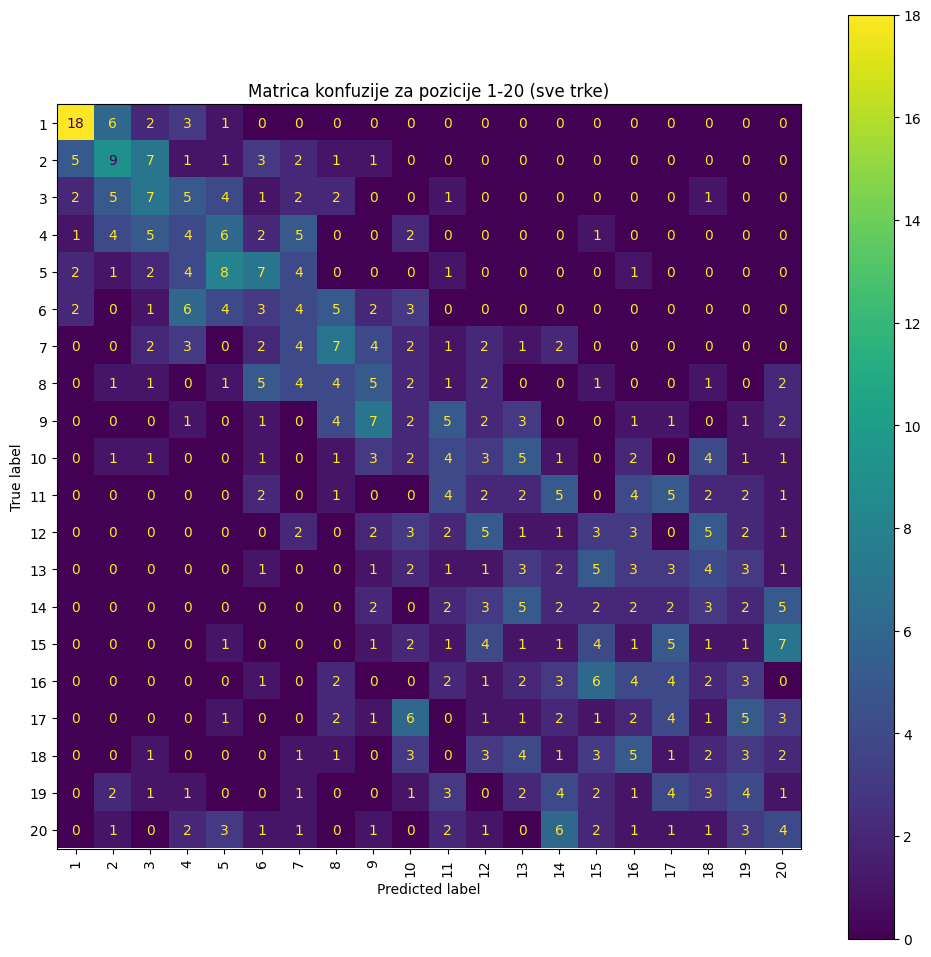

In [117]:
# MATRICA KONFUZIJE

# Inicijalizuj liste u koje ćemo skupljati sve true i pred klase
y_true_all = []
y_pred_all = []

# Pretpostavimo da df_test ima kolone: group_id, position_race (true pozicija), pred_score (model predikcija)

for race_id, group in df_test.groupby("group_id"):
    if len(group) < 2:
        continue

    group = group.copy()
    # Stvarna pozicija (int)
    y_true = group["position_race"].astype(int).values

    # Predikovana pozicija - rangiraj pred_score (veći score = bolja pozicija, tj rank 1 je prvi)
    pred_ranks = group["pred_score"].rank(ascending=False, method='first').astype(int).values

    # Dodaj u ukupne liste
    y_true_all.extend(y_true)
    y_pred_all.extend(pred_ranks)

# Definiši klase (1 do 20)
labels = list(range(1, 21))

# Napravi matricu konfuzije
cm = confusion_matrix(y_true_all, y_pred_all, labels=labels)

# Prikaži matricu konfuzije
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90)
plt.title("Matrica konfuzije za pozicije 1-20 (sve trke)")
plt.show()
